# House Price Prediction using Linear Regression

## Machine Learning Project Report

**Submitted By**
- **Name:** Akshat Pandey
- **Course:** B.Tech (CSE)
- **Algorithm:** Linear Regression
- **Model:** TriXiE
- **Dataset:** King County House Sales Dataset
- **Total Records:** 21,613

---

### Project Objective

To build a Linear Regression model that predicts house prices based on various house features and evaluate its performance using standard regression metrics.

In [18]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [34]:
# Load the dataset
data = pd.read_csv("kc_house_data.csv")

# Display dataset size
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")
print(data.shape)

Rows: 21613, Columns: 21
(21613, 21)


In [20]:
# Display first five rows

display(data.head())

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [21]:
# Display column names

print(data.columns)

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='str')


In [35]:
# Display dataset information
data.info()

# Display data types
print(data.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [24]:
# Display statistical summary

data.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [25]:
# Check for missing values

data.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

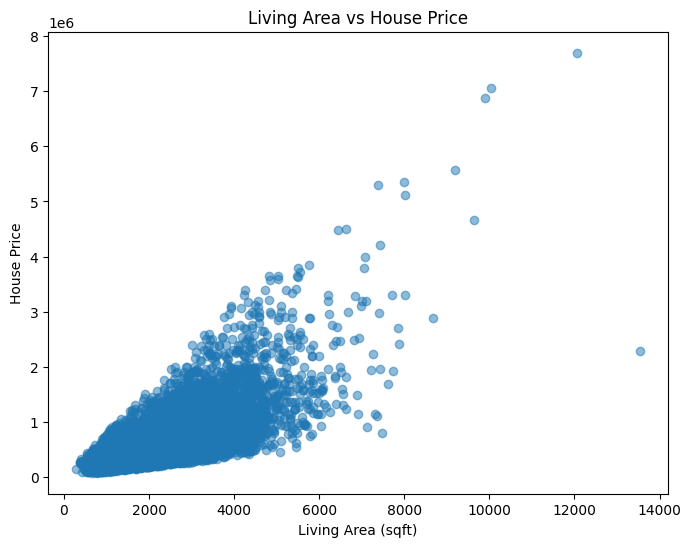

In [26]:
# Visualize relationship between living area and house price

plt.figure(figsize=(8,6))
plt.scatter(data["sqft_living"], data["price"], alpha=0.5)
plt.xlabel("Living Area (sqft)")
plt.ylabel("House Price")
plt.title("Living Area vs House Price")
plt.show()

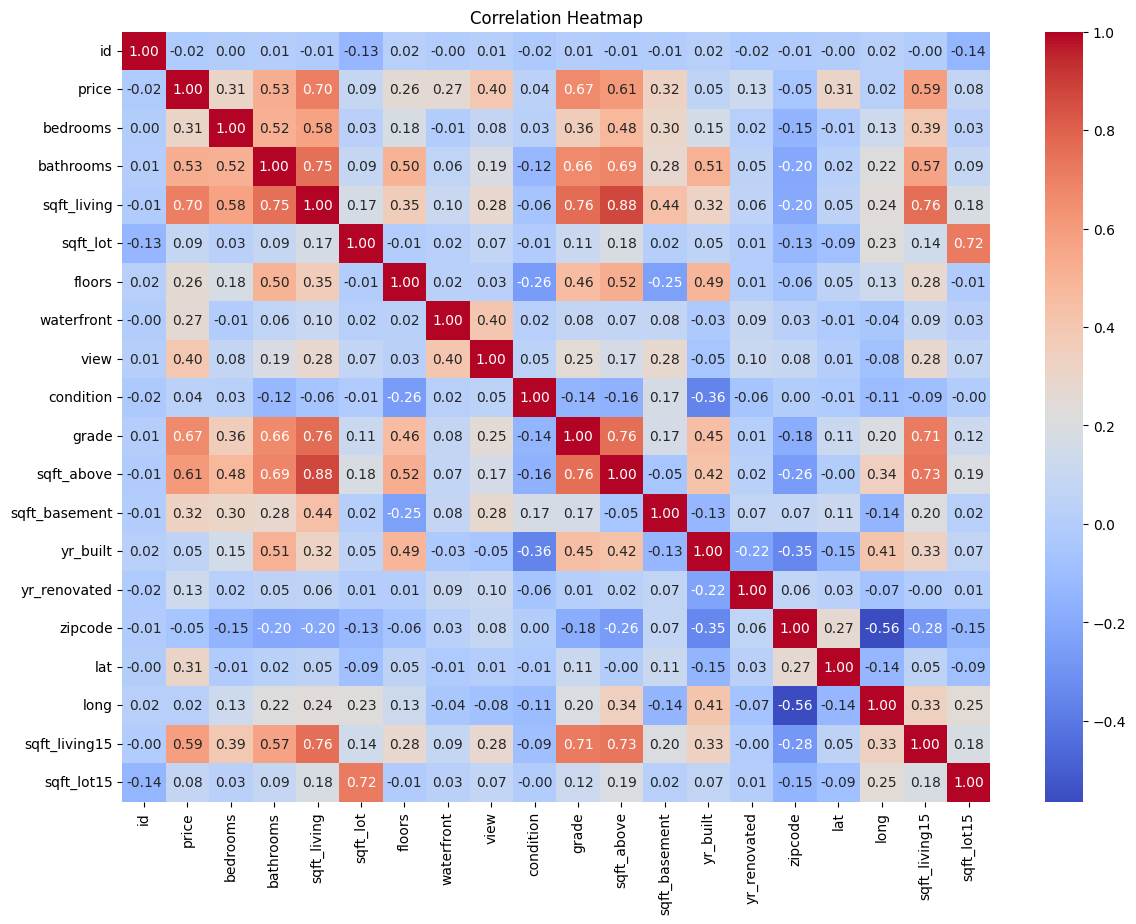

In [27]:
# Display correlation between numerical features

plt.figure(figsize=(14,10))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

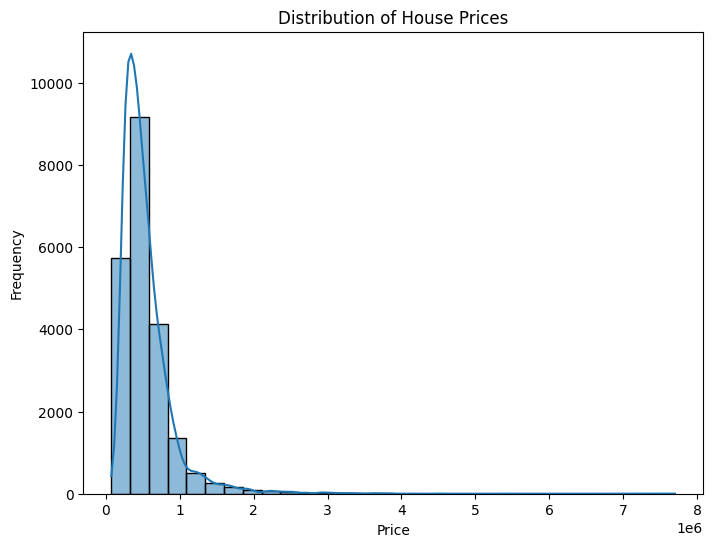

In [28]:
# Display distribution of house prices

plt.figure(figsize=(8,6))
sns.histplot(data["price"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [29]:
# Select input features and target variable

X = data.drop(['id','date','price'], axis=1)
Y = data['price']

In [30]:
 
# Split dataset into training and testing sets
X_train , X_test , Y_train , Y_test = train_test_split(X,Y, test_size=0.30, random_state=42)

In [31]:
# Create the Linear Regression model
TriXiE = LinearRegression()

# Train the TriXiE model
print("Training TriXiE Model...")
TriXiE.fit(X_train,Y_train)
print("Model Trained Successfully")

# Predict house prices
Y_pred = TriXiE.predict(X_test)

Training TriXiE Model...
Model Trained Successfully


In [37]:
# Evaluate model performance

mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print("="*45)
print("TriXiE Model Evaluation")
print("="*45)

print(f"Mean Absolute Error (MAE)      : {mae:.2f}")
print(f"Mean Squared Error (MSE)       : {mse:.2f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.2f}")
print(f"R² Score                       : {r2:.4f}")

TriXiE Model Evaluation
Mean Absolute Error (MAE)      : 127486.80
Mean Squared Error (MSE)       : 43387526779.36
Root Mean Squared Error (RMSE) : 208296.73
R² Score                       : 0.6995


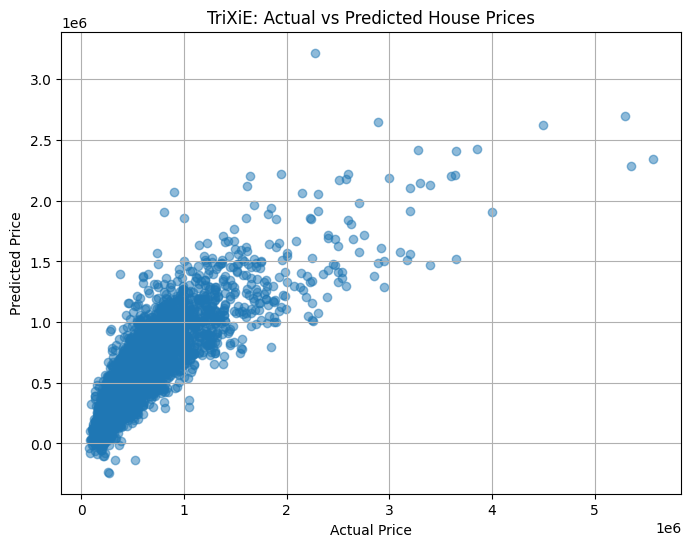

In [36]:
# Compare actual and predicted house prices

plt.figure(figsize=(8,6))
plt.scatter(Y_test, Y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("TriXiE: Actual vs Predicted House Prices")
plt.grid(True)
plt.show()

# Conclusion

- Successfully implemented a **Linear Regression** model for house price prediction.
- Trained the custom model **TriXiE** using 70% of the dataset.
- Tested the model on the remaining 30%.
- Evaluated the model using **MAE, MSE, RMSE, and R² Score**.
- The obtained results indicate that the model can effectively predict house prices based on the selected features.